=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


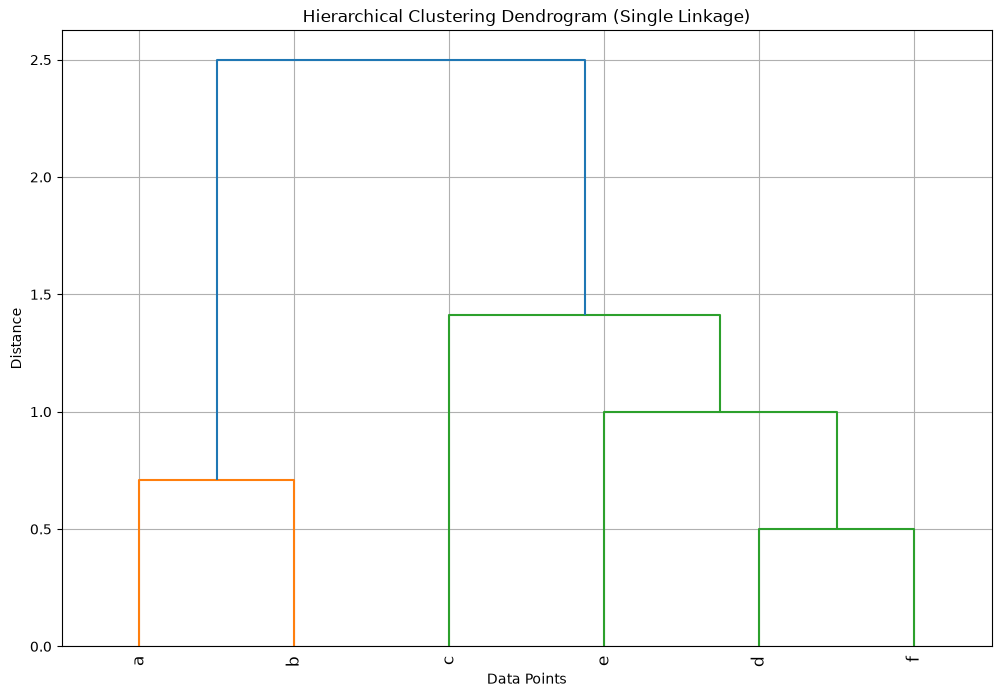

In [1]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
# 1. Dataset sederhana
data = np.array([
 [1.0, 1.0], # a
 [1.5, 1.5], # b
 [5.0, 5.0], # c
 [3.0, 4.0], # d
 [4.0, 4.0], # e
 [3.0, 3.5] # f
])
# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
 columns=['a', 'b', 'c', 'd', 'e', 'f'],
 index=['a', 'b', 'c', 'd', 'e', 'f'])
# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)
# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')
# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

Mengimpor library dasar seperti numpy dan pandas untuk manipulasi matriks dan data, serta scipy.cluster.hierarchy dan scipy.spatial.distance untuk fungsi perhitungan klasterisasi. Menginisialisasi dataset sederhana berupa koordinat dua dimensi ke dalam sebuah array. Menghitung jarak Euclidean antar titik data menggunakan fungsi pdist dan squareform, lalu menampilkannya dalam format Data Frame. Menjalankan algoritma hierarchical clustering menggunakan fungsi linkage dengan parameter method='single' (berdasarkan jarak terdekat). Memvisualisasikan hasil pembentukan klaster tersebut dalam bentuk grafik dendrogram menggunakan library matplotlib.pyplot.

In [3]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Mengimpor library pandas untuk manipulasi data. Membaca dataset dari file CSV eksternal menggunakan fungsi pd.read_csv() dan menyimpannya ke dalam variabel Data Frame. Menampilkan lima baris teratas dari data menggunakan fungsi head() untuk memastikan proses pembacaan file dan struktur kolom berhasil diload dengan benar.

In [4]:
x = df.iloc[:, [3, 4]].values

Melakukan pemotongan (slicing) data menggunakan atribut iloc. Hanya kolom pada indeks ke-3 (Annual Income) dan indeks ke-4 (Spending Score) yang diekstrak, kemudian dikonversi menjadi format array menggunakan .values sebagai fitur utama untuk proses klasterisasi.

In [5]:
from sklearn.preprocessing import StandardScaler
data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

Mengimpor StandardScaler dari library sklearn.preprocessing. Melakukan standardisasi atau normalisasi skala data menggunakan fungsi fit_transform() agar rentang nilai dari kedua fitur tersebut seragam dan tidak menyebabkan bias pada perhitungan jarak. Menampilkan dimensi matriks dari data yang telah diskalakan menggunakan atribut shape.

In [6]:
from scipy.cluster.hierarchy import linkage, dendrogram
clustering = linkage(scaled_data, method="complete", metric="euclidean")

Mengimpor kembali fungsi linkage dan dendrogram dari library scipy.cluster.hierarchy. Melakukan proses klasterisasi hierarki pada data yang sudah diskalakan. Parameter method="complete" digunakan untuk mengukur jarak berdasarkan titik terjauh antar klaster (farthest neighbor), dan parameter metric="euclidean" ditetapkan untuk metode perhitungan jaraknya.

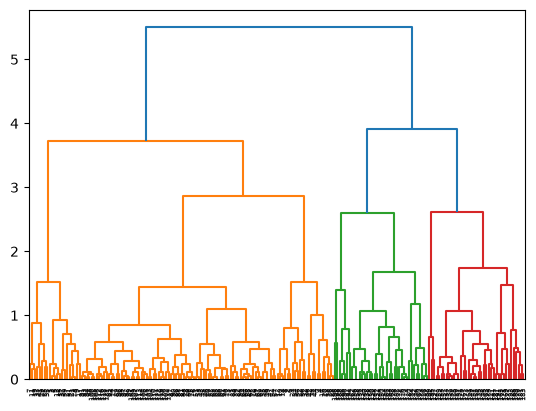

In [7]:
import matplotlib.pyplot as plt
dendrogram(clustering)
plt.show()

Mengimpor library matplotlib.pyplot untuk kebutuhan visualisasi. Membangun dan menampilkan grafik dendrogram dari variabel hasil klasterisasi sebelumnya menggunakan fungsi dendrogram() dan plt.show(). Grafik ini akan memetakan pembagian segmentasi data pelanggan secara visual.

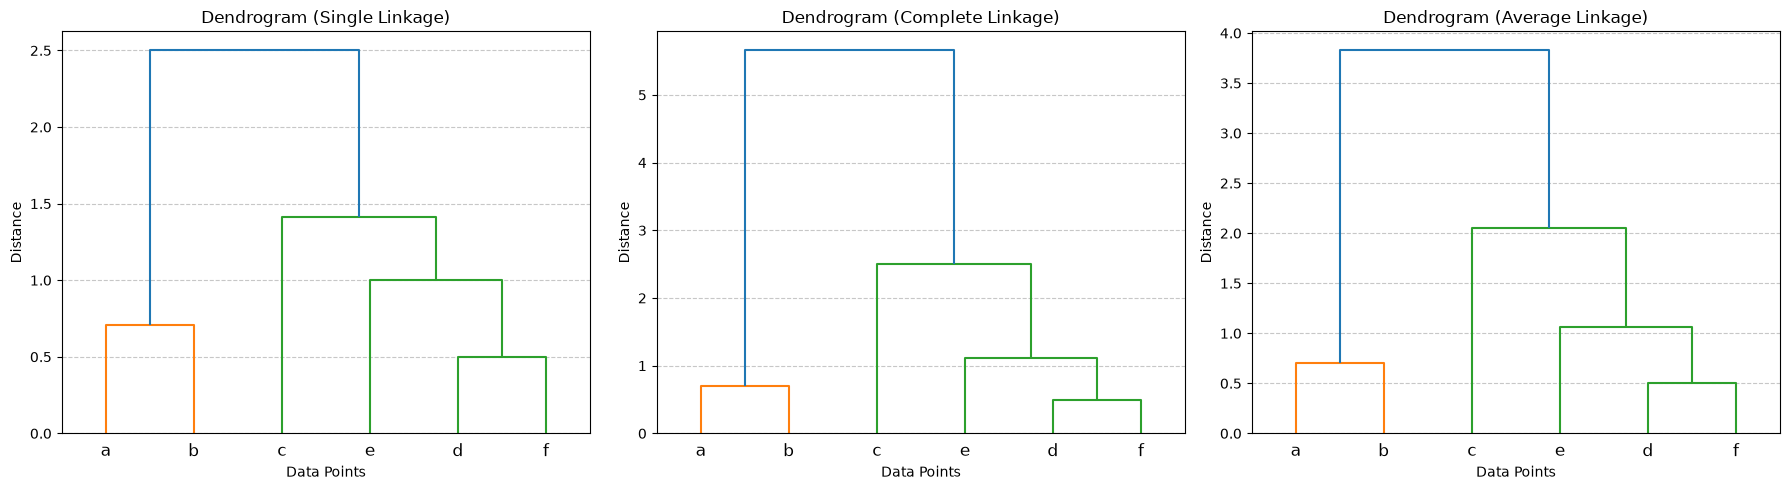

In [8]:
#TUGAS
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# 1. Dataset sederhana (Sesuai dengan Halaman 2)
data = np.array([
    [1.0, 1.0], # a
    [1.5, 1.5], # b
    [5.0, 5.0], # c
    [3.0, 4.0], # d
    [4.0, 4.0], # e
    [3.0, 3.5]  # f
])
labels = ['a', 'b', 'c', 'd', 'e', 'f']

# 2. Menentukan metode linkage yang akan dibandingkan
methods = ['single', 'complete', 'average']

# 3. Membuat Plot perbandingan
plt.figure(figsize=(18, 5))

for i, method in enumerate(methods):
    # Melakukan Hierarchical Clustering sesuai metode
    linked = linkage(data, method=method)
    
    # Plotting subplot
    plt.subplot(1, 3, i+1)
    plt.title(f"Dendrogram ({method.capitalize()} Linkage)")
    dendrogram(linked, labels=labels, leaf_rotation=0)
    plt.xlabel("Data Points")
    plt.ylabel("Distance")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Melakukan modifikasi pada pemanggilan fungsi linkage untuk menjalankan algoritma klasterisasi sebanyak tiga kali dengan nilai parameter metode yang berbeda: "single" (jarak terdekat), "complete" (jarak terjauh), dan "average" (jarak rata-rata). Membuat visualisasi yang menampilkan ketiga plot dendrogram tersebut secara berdampingan untuk mengamati dan membandingkan secara langsung perbedaan struktur penggabungan klaster serta skala jarak (sumbu y) yang dihasilkan oleh masing-masing metode.